In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
@author: Jordy Thielen (jordy.thielen@donders.ru.nl)
"""
import os
from os.path import join
import numpy as np
import pyntbci


wd = r'C:\Users\Radovan\OneDrive\Radboud\Studentships\Jordy Thielen\root'
os.chdir(wd)
data_dir = join(wd, "data")
experiment_dir = join(data_dir, "experiment")
files_dir = join(experiment_dir, 'files')
sourcedata_dir = join(experiment_dir, 'sourcedata')
derivatives_dir = join(join(experiment_dir, 'derivatives'))
os.chdir(wd)
data_dir = experiment_dir

subjects = [
    "VPpdia", "VPpdib", "VPpdic", "VPpdid", "VPpdie", "VPpdif", "VPpdig", "VPpdih", "VPpdii", "VPpdij", "VPpdik",
    "VPpdil", "VPpdim", "VPpdin", "VPpdio", "VPpdip", "VPpdiq", "VPpdir", "VPpdis", "VPpdit", "VPpdiu", "VPpdiv",
    "VPpdiw", "VPpdix", "VPpdiy", "VPpdiz", "VPpdiza", "VPpdizb", "VPpdizc"
]
tasks = ["overt", "covert"]

ensemble = True
lags = np.array([0, 65/60])
n_folds = 4

# Loop participants
accuracy = np.zeros((len(subjects), len(tasks), n_folds))
for i_subject, subject in enumerate(subjects):
    print(f"{subject}", end="\t")

    # Loop tasks
    for i_task, task in enumerate(tasks):
        print(f"{task}: ", end="")

        # Load data
        file_dir = os.path.join(derivatives_dir, 'preprocessed', "cvep", f"sub-{subject}")
        fn = os.path.join(file_dir, f"sub-{subject}_task-{task}_cvep_64_noica.npz")
        tmp = np.load(fn)
        fs = int(tmp["fs"])
        X = tmp["X"]
        y = tmp["y"]
        V = tmp["V"]

        # Cross-validation
        folds = np.repeat(np.arange(n_folds), int(X.shape[0] / n_folds))
        for i_fold in range(n_folds):
            # Split data to train and test set
            X_trn, y_trn = X[folds != i_fold, :, :], y[folds != i_fold]
            X_tst, y_tst = X[folds == i_fold, :, :], y[folds == i_fold]

            # Train classifier
            ecca = pyntbci.classifiers.eCCA(lags=lags, fs=fs, cycle_size=V.shape[1] / fs, ensemble=ensemble)
            X_trn = X_trn[:, :, :9 * V.shape[1]]  # cut to full cycles
            ecca.fit(X_trn, y_trn)

            # Apply classifier
            yh_tst = ecca.predict(X_tst)

            # Compute accuracy
            accuracy[i_subject, i_task, i_fold] = np.mean(yh_tst == y_tst)

        print(f"{accuracy[i_subject, i_task, :].mean():.3f}", end="\t")
    print()

print(f"Average:\tovert: {accuracy[:, 0, :].mean():.3f}\tcovert: {accuracy[:, 1, :].mean():.3f}")

np.savez(os.path.join(data_dir, "derivatives", "cvep_ecca.npz"), accuracy=accuracy)


VPpdia	overt: 1.000	covert: 0.550	
VPpdib	overt: 1.000	covert: 0.463	
VPpdic	overt: 1.000	covert: 0.637	
VPpdid	overt: 1.000	covert: 0.488	
VPpdie	overt: 1.000	covert: 0.613	
VPpdif	overt: 1.000	covert: 0.713	
VPpdig	overt: 1.000	covert: 0.675	
VPpdih	overt: 1.000	covert: 0.675	
VPpdii	overt: 1.000	covert: 0.588	
VPpdij	overt: 1.000	covert: 0.550	
VPpdik	overt: 1.000	covert: 0.650	
VPpdil	overt: 1.000	covert: 0.575	
VPpdim	overt: 1.000	covert: 0.613	
VPpdin	overt: 0.950	covert: 0.688	
VPpdio	overt: 1.000	covert: 0.713	
VPpdip	overt: 1.000	covert: 0.700	
VPpdiq	overt: 0.950	covert: 0.613	
VPpdir	overt: 1.000	covert: 0.725	
VPpdis	overt: 0.950	covert: 0.438	
VPpdit	overt: 1.000	covert: 0.750	
VPpdiu	overt: 1.000	covert: 0.588	
VPpdiv	overt: 1.000	covert: 0.700	
VPpdiw	overt: 0.950	covert: 0.700	
VPpdix	overt: 1.000	covert: 0.600	
VPpdiy	overt: 1.000	covert: 0.525	
VPpdiz	overt: 1.000	covert: 0.613	
VPpdiza	overt: 1.000	covert: 0.625	
VPpdizb	overt: 1.000	covert: 0.625	
VPpdizc	overt: 1.0

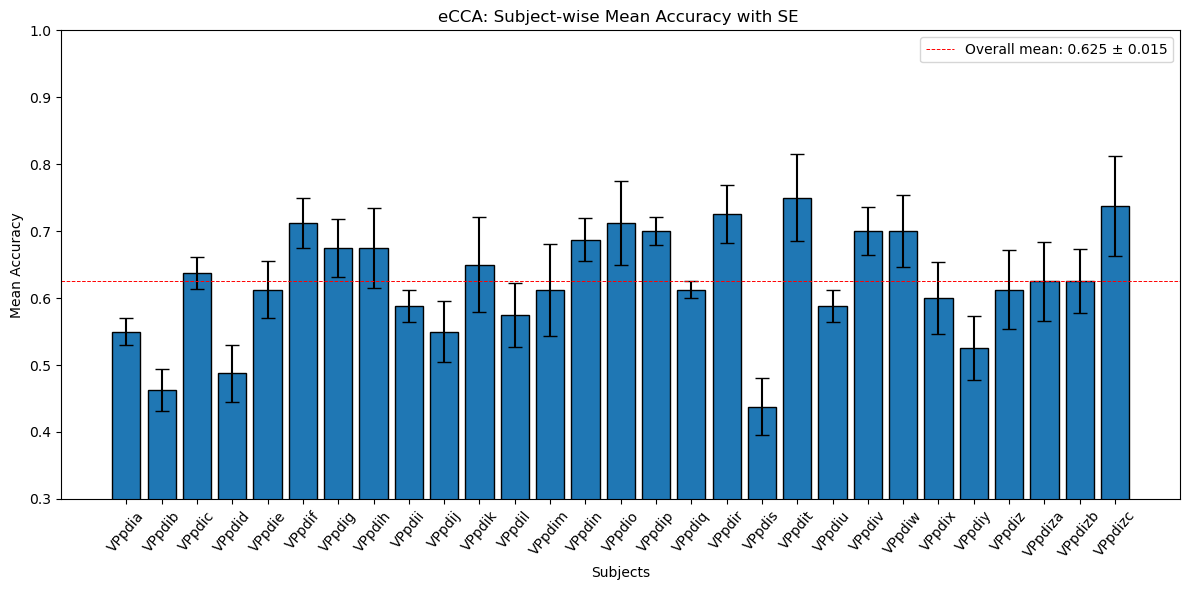

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Compute subject-level mean accuracy and per-subject SE (across folds)
subject_means = np.mean(accuracy[:, 1, :], axis=1)
subject_se = np.std(accuracy[:, 1, :], ddof=1, axis=1) / np.sqrt(accuracy.shape[2])

# Compute overall mean accuracy and SE (based on subject means only)
overall_mean = np.mean(subject_means)
overall_se = np.std(subject_means, ddof=1) / np.sqrt(len(subject_means))

# Create a bar plot for each subject
fig, ax = plt.subplots(figsize=(12, 6))
subject_indices = np.arange(len(subject_means))
ax.bar(subject_indices, subject_means, yerr=subject_se, capsize=5, color="tab:blue", edgecolor="black")
ax.set_xticks(subject_indices)
# You can use subject IDs or numbers; here we'll assume subjects is a list of strings
subject_labels = subjects
ax.set_ylim(0.3,1)
ax.set_xticklabels(subject_labels, rotation=50)
ax.set_xlabel("Subjects")
ax.set_ylabel("Mean Accuracy")
ax.set_title("eCCA: Subject-wise Mean Accuracy with SE ")

# Add overall mean accuracy as a horizontal line with a shaded area for overall SE
ax.axhline(overall_mean, color="red", linestyle="--", linewidth = 0.7, label=f"Overall mean: {overall_mean:.3f} ± {overall_se:.3f}")
ax.axhline(1, color="grey", linestyle="--", linewidth = 0.7)
#ax.fill_between(subject_indices, overall_mean - overall_se, overall_mean + overall_se, color="red", alpha=0.2)

ax.legend()
plt.tight_layout()
plt.show()


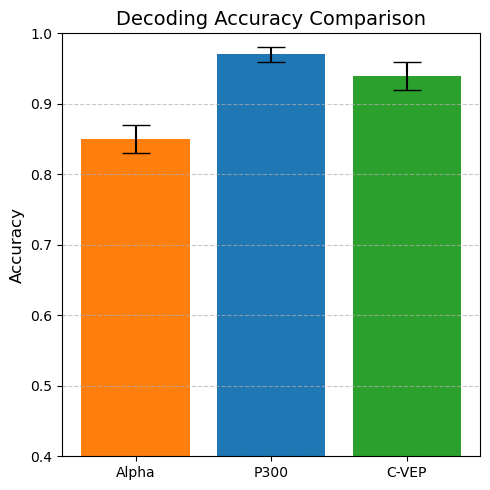

In [ ]:
import matplotlib.pyplot as plt

# Data for pipelines
pipelines = ['Alpha', 'P300', 'C-VEP']
accuracies = [0.85, 0.97, 0.94]
standard_errors = [0.02, 0.01, 0.02]  # Converted from decimals (0.02, 0.01) to percentages (2%, 1%)

# Create bar plot
fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(pipelines, accuracies, yerr=standard_errors, capsize=10, color=['tab:orange', 'tab:blue', 'tab:green'])

# Add labels and title
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Decoding Accuracy Comparison', fontsize=14)
ax.set_ylim(0.4, 1)

# Add grid
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.tight_layout()
plt.show()


## Decoding Curve